In [1]:
import sys
import os
# Adds the parent directory to sys.path
sys.path.append(os.path.abspath('..'))
import pandas as pd
from utils import (data_encoder, hyper_param_opt,
                   outlier_detection_by_clust,
                   weighted_distance_calculation,
                   outlier_detection_by_dist,
                   final_plot)
import pickle
from ucimlrepo import fetch_ucirepo 

In [2]:
def download_dataset(dataset_name):
    # Map dataset names to UCI ML repository IDs
    dataset_ids = {
    "iris": {"id": 53, "target_column": "target", "sensitive_columns": ["sepal width"]},
    "wine": {"id": 109, "target_column": "target", "sensitive_columns": ["Alcohol", "Malicacid","Ash","Alcalinity_of_ash"]},
    "abalone": {"id": 1, "target_column": "target", "sensitive_columns": ["Sex"]},
    "heart disease": {"id": 45, "target_column": "target", "sensitive_columns": ["age", "sex"]},
    "adult": {"id": 2, "target_column": "target", "sensitive_columns": ["age", "race", "sex"]},
    "car evaluation": {"id": 19, "target_column": "target", "sensitive_columns": ["buying"]},
    "automobile": {"id": 10, "target_column": "target", "sensitive_columns": ["price"]},
    "mushroom": {"id": 73, "target_column": "target", "sensitive_columns": ["odor", "bruises"]},
    "german credit": {"id": 144, "target_column": "target", "sensitive_columns": ["Attribute1","Attribute2"]},
    "dry bean": {"id": 602, "target_column": "target", "sensitive_columns": ["Area","Perimeter","MajorAxisLength"]},
    "bike sharing": {"id": 275, "target_column": "target", "sensitive_columns": []},
    "auto_mpg": {"id": 9, "target_column": "target", "sensitive_columns": ["origin"]},
    "RT-IoT2022": {"id": 942, "target_column": "target", "sensitive_columns": []},
    "EEG Eye State": {"id": 264, "target_column": "target", "sensitive_columns": []},
    "Metro": {"id": 492, "target_column": "target", "sensitive_columns": []}
    }
    
    
    # Fetch the dataset ID
    dataset_id = dataset_ids[dataset_name]['id']
    
    # Fetch the dataset
    dataset = fetch_ucirepo(id=dataset_id)
    X = dataset.data.features
    y = dataset.data.targets
    X['target'] = y
    
    return X, dataset_ids[dataset_name]['target_column'], dataset_ids[dataset_name]['sensitive_columns']

In [3]:
dataset_name = 'iris'

In [4]:
data, target_column, sensitive_columns = download_dataset(dataset_name)

In [5]:
# ENCODING
encoded_data = data_encoder.ordinal_encode_categorical(
    data, dataset_name, pickle_path=f'{dataset_name}_mappings.pkl', save=True)

TypeError: ordinal_encode_categorical() got an unexpected keyword argument 'pickle_path'

In [ ]:
top_n=10
eps_values=[0.1, 0.3, 0.5, 0.7, 1.]
min_samples_values=range(1, 20)
num_clusters = 3

In [ ]:
# GRID-SEARCH
hyper_param_opt.hyper_param_search(
    encoded_data,
    num_clusters=num_clusters,
    percentage_outliers=0.01,
    dataset_name=dataset_name,
    top_n=top_n,
    eps_values=eps_values,
    min_samples_values=min_samples_values,
    save=True)

## Input

In [ ]:
chosen_eps = 1
chosen_min_sample = 2
chosen_metric = 'euclidean'
chosen_algorithm = 'auto'

In [ ]:
# REMOVE DBSCAN OUTLIERS
outlier_detection_by_clust.create_dbscan_and_clean_data(encoded_data, eps=chosen_eps, min_samples=chosen_min_sample,
                                                        metric=chosen_metric, algorithm=chosen_algorithm,
                                                        leaf_size=50, dataset_name=dataset_name, plot=False)

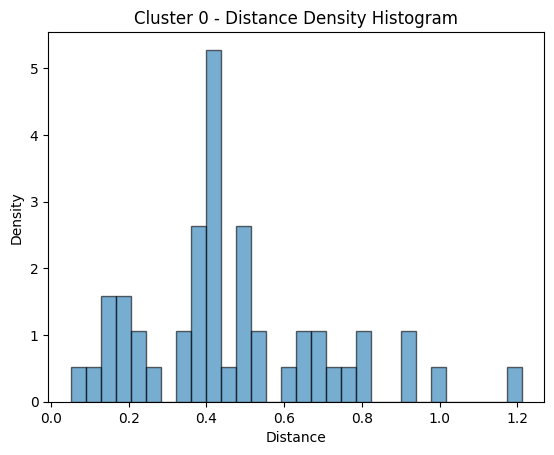

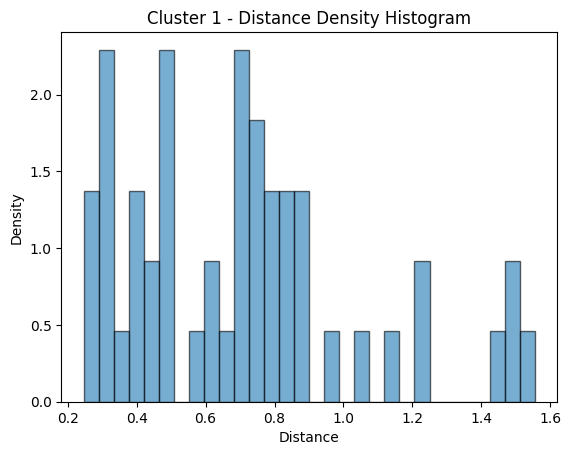

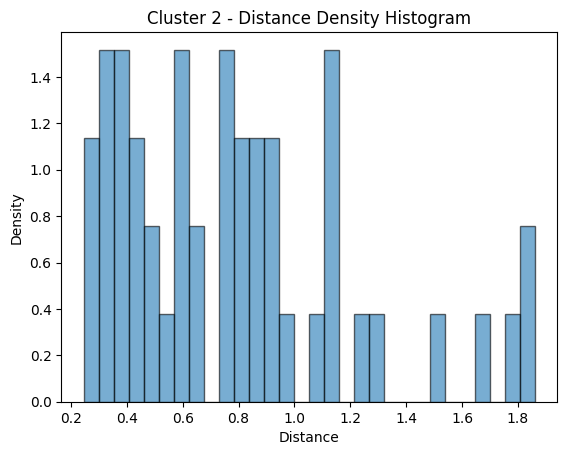

In [6]:
# GET DISTRIBUTIONS
weighted_distance_calculation.calculate_plot_distance(dataset_name)

In [7]:
# REMOVE DISTANT OUTLIERS

threshold = {'0': 1, '1': 1.2, '2': 1.6}

outlier_detection_by_dist.filter_and_save_by_distance(
    dataset_name, threshold, plot=False)

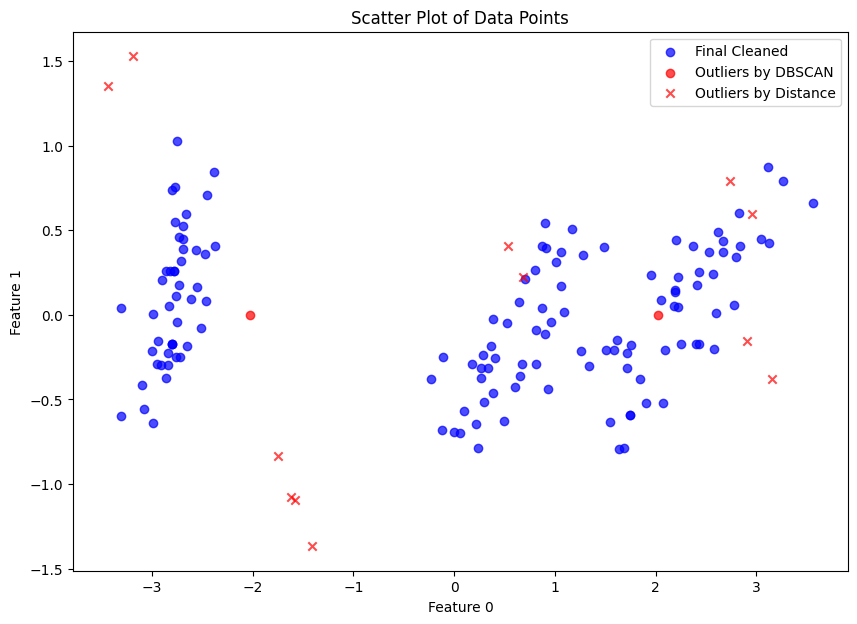

In [8]:
# PLOT
final_plot.plot_data_points(dataset_name)

In [10]:
# DECODING

decoded_data = data_encoder.ordinal_decode_categorical(dataset_name)

In [ ]:
iput_params = {dataset_name: dataset_name}